In [19]:
#utils I made to look at this data
import switchy.util as ut
import pandas as pd
import numpy as np
import scipy
import sys
import os
import time
import random
import copy
import math
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import scanpy as sc
import seaborn as sns
import autoreload
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../../../SharedData/"
#import auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# MUNGE THE sequence id to get a Cell column and a Donor Column
changeodb = pd.read_csv('../../../ImmTrinity/ShazamTrinity.tab', index_col = None, sep = '\t')

_x = changeodb.SEQUENCE_ID.str.split('_')[0][1:-7]

cell_list = []
for SeqID in changeodb.SEQUENCE_ID:
    _x = SeqID.split('_')[1:-7]
    cell_list.append('_'.join(_x))

changeodb['CELL'] = cell_list
changeodb['Donor'] = changeodb.SEQUENCE_ID.str.split(' ', expand = True)[1]

In [21]:
df_contig_aggr = changeodb.groupby(["Donor", "CELL", "LOCUS"]).size().unstack(fill_value=0)


2 4


Text(1.0, 1.0, '1734')

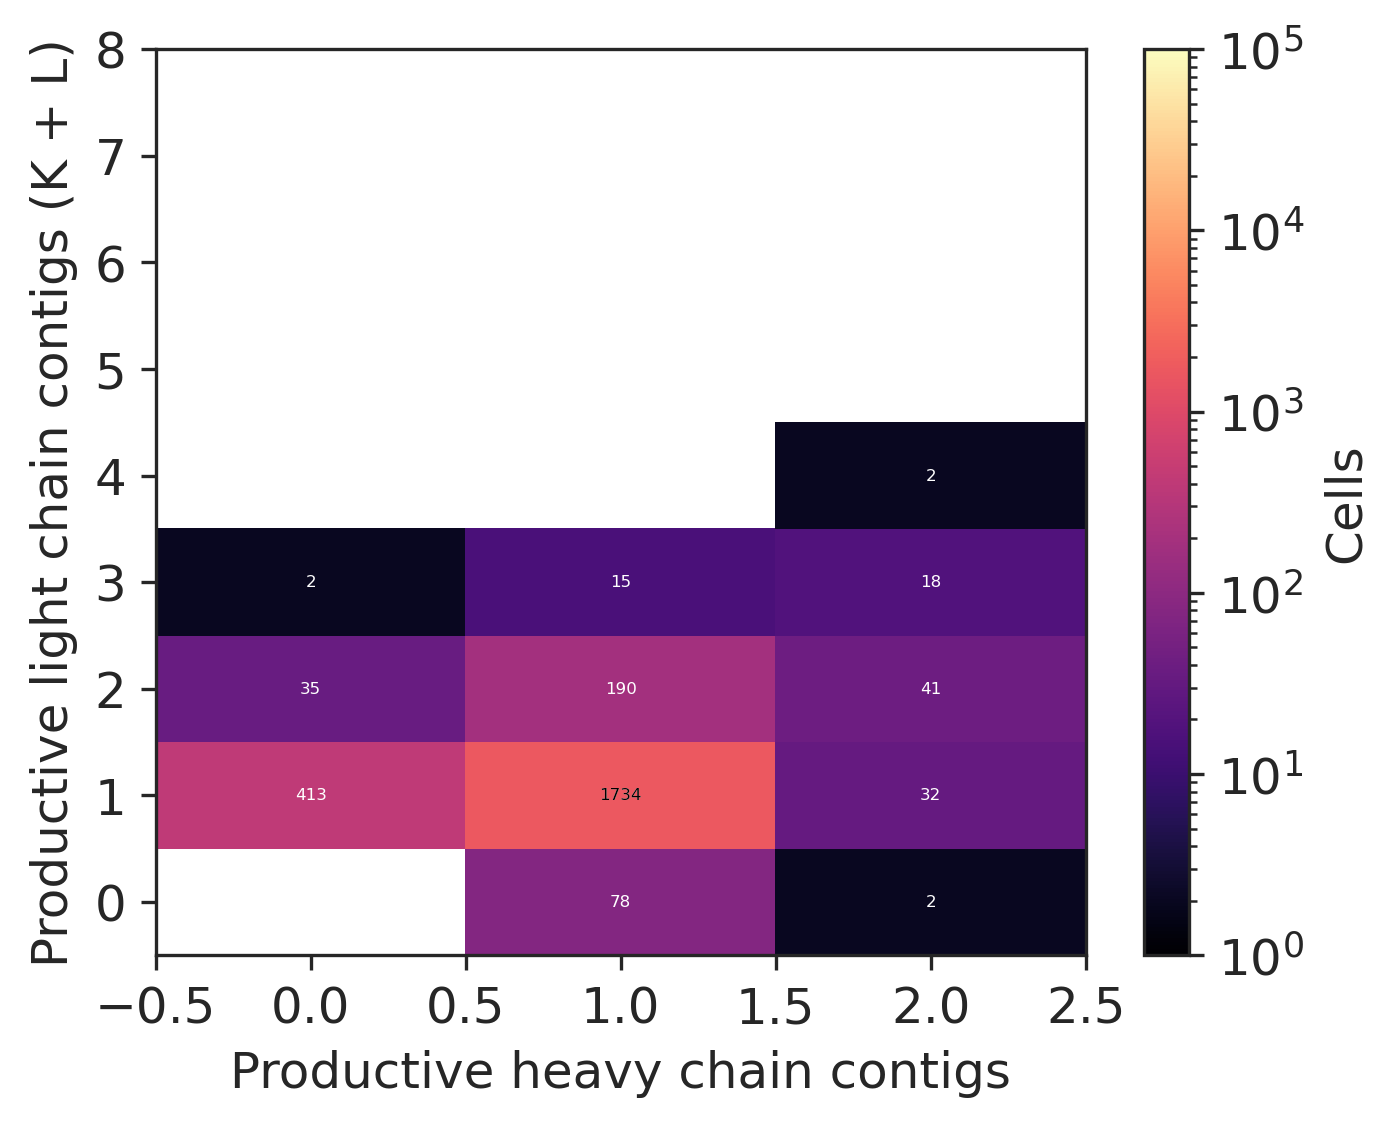

In [22]:
# Examine number of high-quality contigs assembled per cell (joint distribution of IGH, IGK/L)
# full range

x = df_contig_aggr["IGH"]
y = df_contig_aggr["IGL"] + df_contig_aggr["IGK"]

print(max(x), max(y))
xbins = np.array(range(0,max(x)+2))-0.5
ybins = np.array(range(0,max(y)+2))-0.5

fig, ax = plt.subplots(1, 1, figsize=(5,4))

counts, xedges, yedges, im = ax.hist2d(x, y, bins=(xbins, ybins),
                                       cmap="magma",
                                       norm=mpl.colors.LogNorm(1, 1e5))

ax.set_xlabel("Productive heavy chain contigs")
ax.set_ylabel("Productive light chain contigs (K + L)")
plt.colorbar(im, ax=ax, label="Cells")

ax.set_ylim(top=8)

# show counts
dx = xedges[2]-xedges[1]
dy = yedges[2]-yedges[1]
for i in range(xedges.size-1):
    for j in range(yedges.size-1):
        xb = xedges[i] + 0.5*dx
        yb = yedges[j] + 0.5*dy 
        ax.text(xb, yb, str(int(counts[i,j])), fontsize=4, ha="center", va="center", color="w")

# show count of 1H+1L in black
xb = xedges[1] + 0.5*dx
yb = yedges[1] + 0.5*dy 
ax.text(xb, yb, str(int(counts[1,1])), fontsize=4, ha="center", va="center", color="k")

In [23]:
# Filter for cells having exactly 1H+1L
df_contig_aggr_filtered = df_contig_aggr
df = df_contig_aggr_filtered.loc[(df_contig_aggr_filtered["IGH"] == 1) &
                                 (((df_contig_aggr_filtered["IGL"] == 1) & (df_contig_aggr_filtered["IGK"] == 0)) |
                                  ((df_contig_aggr_filtered["IGL"] == 0) & (df_contig_aggr_filtered["IGK"] == 1)))]
df.head()
# Filter orginal Changeodb to include only singlets
df_all_contig_annotations_valid = changeodb.set_index(["Donor", "CELL"]).loc[df.index]
print(df_all_contig_annotations_valid.shape)

# Filter contigs for only IGH, IGL, or IGK
df_all_contig_annotations_valid = df_all_contig_annotations_valid.loc[df_all_contig_annotations_valid["LOCUS"].isin(["IGH", "IGL", "IGK"])]
print (df_all_contig_annotations_valid.shape)
df_all_contig_annotations_valid.head()

# Filter contigs for only productive
df_all_contig_annotations_valid = df_all_contig_annotations_valid.loc[df_all_contig_annotations_valid["FUNCTIONAL"] == True]
print (df_all_contig_annotations_valid.shape)
df_all_contig_annotations_valid.head()

(3468, 60)
(3468, 60)
(3468, 60)


SEQUENCE_ID                                     SEQUENCE_INPUT  FUNCTIONAL  IN_FRAME   STOP  MUTATED_INVARIANT  INDELS LOCUS                    V_CALL                 D_CALL             J_CALL                                       SEQUENCE_VDJ                                      SEQUENCE_IMGT  V_SEQ_START  V_SEQ_LENGTH  V_GERM_START_VDJ  V_GERM_LENGTH_VDJ  V_GERM_START_IMGT  V_GERM_LENGTH_IMGT  NP1_LENGTH  D_SEQ_START  D_SEQ_LENGTH  D_GERM_START  D_GERM_LENGTH  NP2_LENGTH  J_SEQ_START  J_SEQ_LENGTH  J_GERM_START  J_GERM_LENGTH                                           JUNCTION  JUNCTION_LENGTH                                      GERMLINE_IMGT  V_SCORE  V_IDENTITY       V_EVALUE                                            V_CIGAR  D_SCORE  D_IDENTITY      D_EVALUE         D_CIGAR  J_SCORE  J_IDENTITY      J_EVALUE     J_CIGAR                                          FWR1_IMGT  \
Donor   CELL                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
Donor_0 IL6811-701-503  bracer_IL6811-701-503_TRINITY_DN2_c0_g1_i1_H D...  GTGTCCAGTGTGAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGT...        True      True  False                NaN   False   IGH  IGHV3-23*01,IGHV3-23D*01            IGHD3-10*01           IGHJ3*01  GAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGGG...  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...           12           296                 1                296                  1                 320           8        316.0          18.0          11.0           18.0         1.0          335            47             4             47  TGTGCGAAAGATGACTTAGGGTTCGGGGACCTATTATTTGCTTTTG...               54  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...    416.0     0.94932  5.110000e-118  11S59=1X29=1X63=1X5=1X2=2X6=2X1=1X8=1X47=1X2=1...     23.8     0.88889  2.900000e-02  315S10N10=2X6=     91.1         1.0  2.960000e-22   334S3N47=  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...   
        IL6811-701-503  bracer_IL6811-701-503_TRINITY_DN0_c0_g1_i1_L D...  GGTCCTGGGCCCAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGG...        True      True  False                NaN   False   IGL               IGLV2-14*01                    NaN           IGLJ1*01  CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...           12           293                 1                293                  1                 335           6          NaN           NaN           NaN            NaN         NaN          311            35             4             35            TGCAGCTCATTTACAATTAGGAGCACCCCTTGTGTCTTC               39  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...    430.0     0.96928  2.960000e-122             11S94=1X2=2X20=1X125=1X31=1X5=2X2=1X5=      NaN         NaN           NaN             NaN     68.0         1.0  2.520000e-15   310S3N35=  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...   
        IL6811-701-505  bracer_IL6811-701-505_TRINITY_DN0_c0_g1_i1_H D...  TGTCCAGTGTGAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTC...        True      True  False                NaN   False   IGH               IGHV3-73*01  IGHD2-2*01,IGHD2-2*03           

In [24]:
## Add Isotype column by using splice junctions 

In [31]:
df = df_all_contig_annotations_valid

In [32]:
ab_tx, switch_tx = ut.loadSJoutIGH(data_dir + 'CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:845: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = _infer_fill_value(value)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


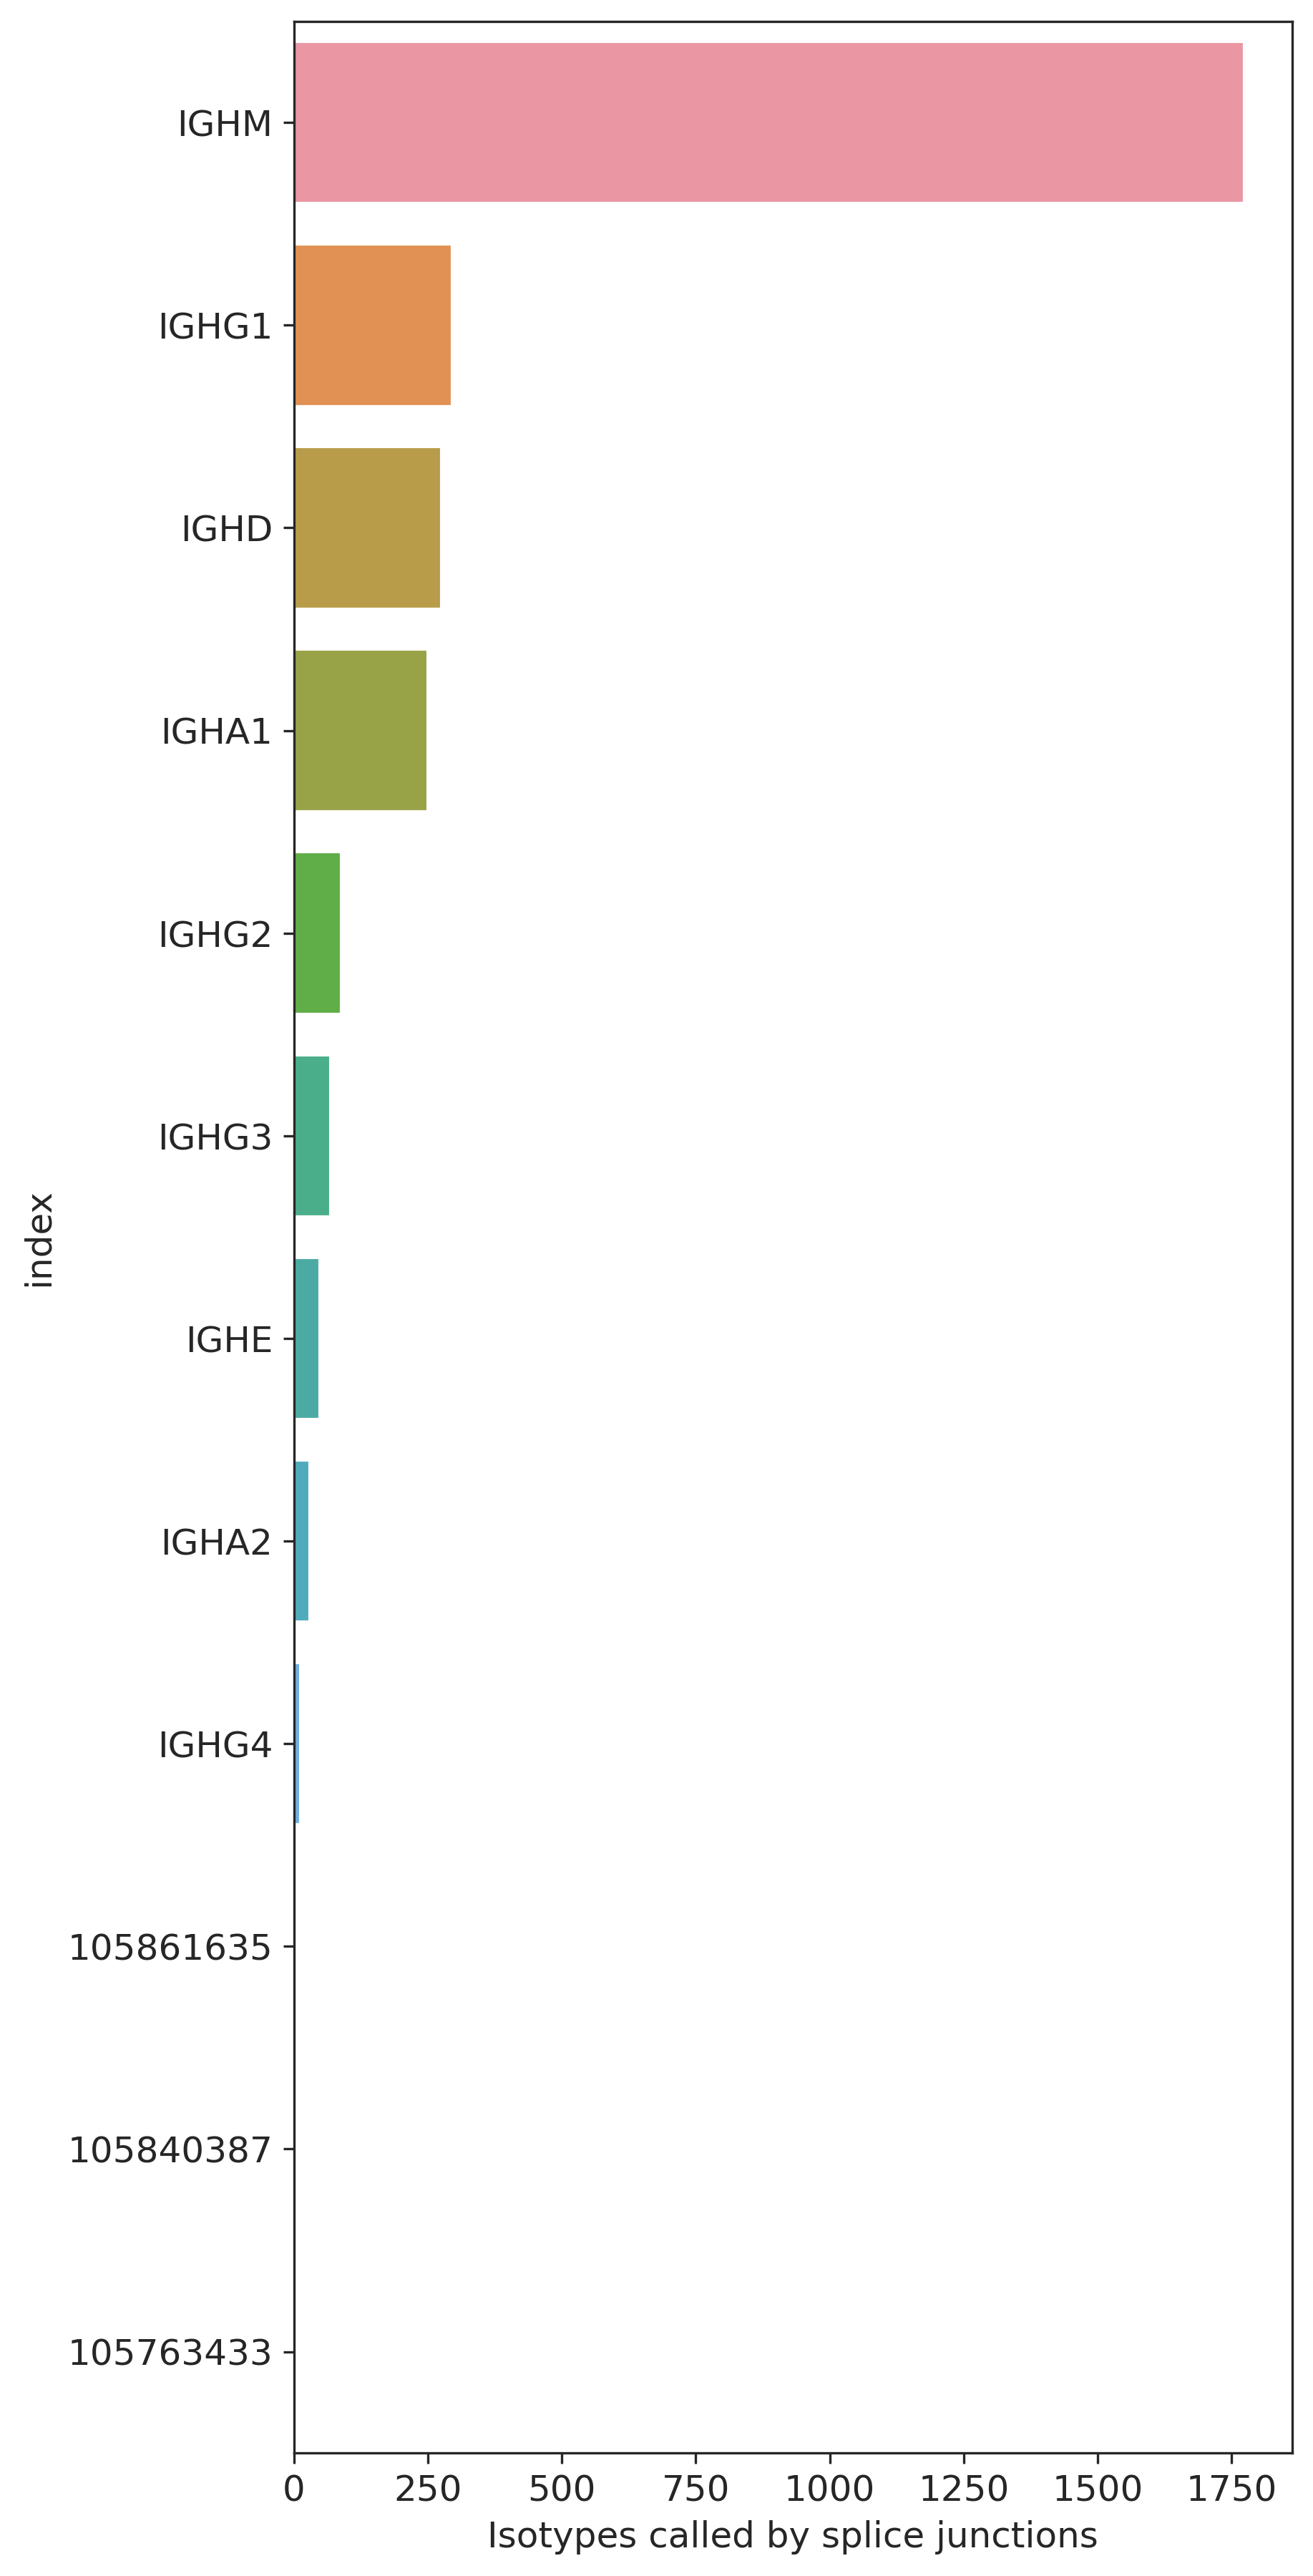

In [33]:
isotype_calls = ut.callIsotypeBySJout(ab_tx, plot=True)

In [34]:


_df = isotype_calls[['ISOTYPE_by_splice', 'cell']]

df = pd.merge(df, _df, left_on='CELL', right_on='cell')

df['ISOTYPE'] = df['ISOTYPE_by_splice']

In [36]:
df.to_csv(data_dir + 'ShazamQCed.tab', sep = '\t')

In [37]:
df = df[df.LOCUS == 'IGH']

In [38]:
df.to_csv(data_dir + 'ShazamQCedIGH.tab', sep = '\t')